# **DATA ANALYSIS PYTHON PROJECT - Video Games**

## Import Labraries

In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt


#  Import Dataset

In [4]:
df=pd.read_csv("C:/Users/DeLL/Documents/VideoGamesSales.csv")

#  Dataset Overview

In [6]:
print("Total rows:",df.shape)
print("Total Columns:",df.info())
print("Numeric Data:",df.describe())
print("Missing Values:",df.isnull().sum())

Total rows: (5909, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5909 entries, 0 to 5908
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rank           5909 non-null   int64  
 1   Name           5909 non-null   object 
 2   Platform       5909 non-null   object 
 3   Year           5909 non-null   int64  
 4   Month          5909 non-null   object 
 5   Genre          5909 non-null   object 
 6   Publisher      5897 non-null   object 
 7   Country        5909 non-null   object 
 8   City           5909 non-null   object 
 9   State          5909 non-null   object 
 10  Region         5882 non-null   object 
 11  NA_Sales       5909 non-null   object 
 12  Global_Sales   5909 non-null   float64
 13  NA_Profit      5909 non-null   float64
 14  Global_Profit  5909 non-null   float64
dtypes: float64(3), int64(2), object(10)
memory usage: 692.6+ KB
Total Columns: None
Numeric Data:               Rank     

# Top Selling Game

In [9]:
top_games = df.loc[df["Global_Sales"].idxmax()]
print(top_games)


Rank                         1
Name                Wii Sports
Platform                   Wii
Year                      2010
Month                      Jan
Genre                   Sports
Publisher             Nintendo
Country          United States
City                 Fairfield
State               California
Region                    West
NA_Sales                $41.49
Global_Sales             82.74
NA_Profit               12.447
Global_Profit           24.822
Name: 0, dtype: object


# Year-Wise Revenune

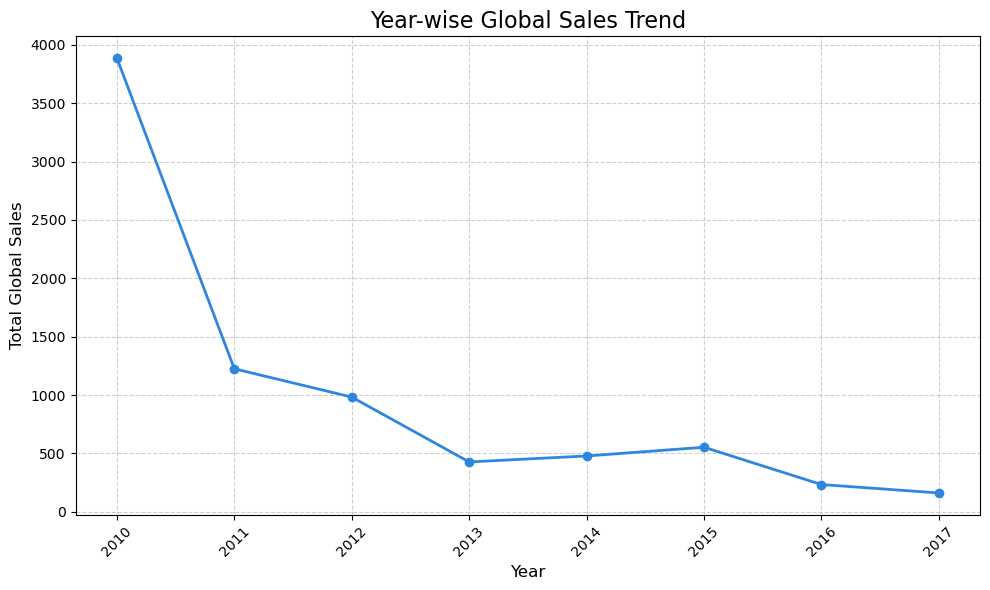

In [21]:

year_sales = df.groupby("Year")["Global_Sales"].sum()

plt.figure(figsize=(10,6))

year_sales.plot(
    kind="line",
    marker="o",
    color="#2E86DE",
    linewidth=2
)

plt.title("Year-wise Global Sales Trend", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Global Sales", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Genre Analysis

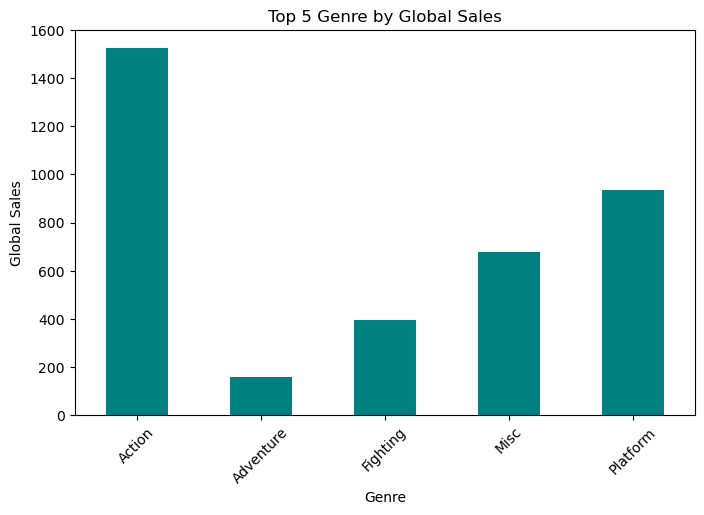

In [22]:
genre_sales = df.groupby("Genre")["Global_Sales"].sum()
# print(genre_sales)
plt.figure(figsize=(8,5))

genre_sales.head(5).plot(
    kind="bar",
    color="teal"
)

plt.title("Top 5 Genre by Global Sales")
plt.xlabel("Genre")
plt.ylabel("Global Sales")
plt.xticks(rotation=45)

plt.show()




# Paltform Comparison


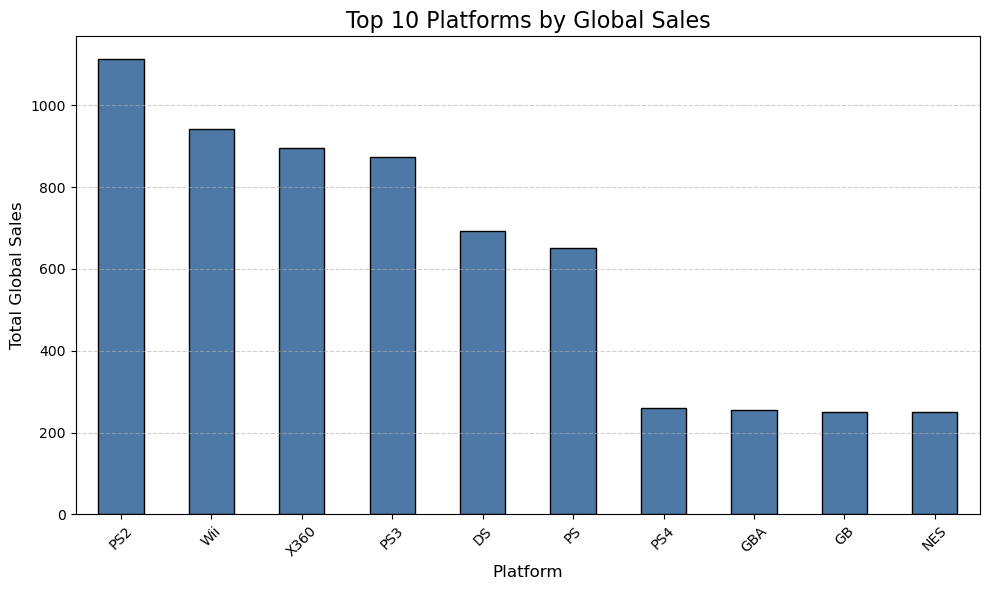

In [32]:

platform_sales = df.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

platform_sales.head(10).plot(
    kind="bar",
    color="#4E79A7",
    edgecolor="black"
)

plt.title("Top 10 Platforms by Global Sales", fontsize=16)
plt.xlabel("Platform", fontsize=12)
plt.ylabel("Total Global Sales", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

#  Region wise Global Sales


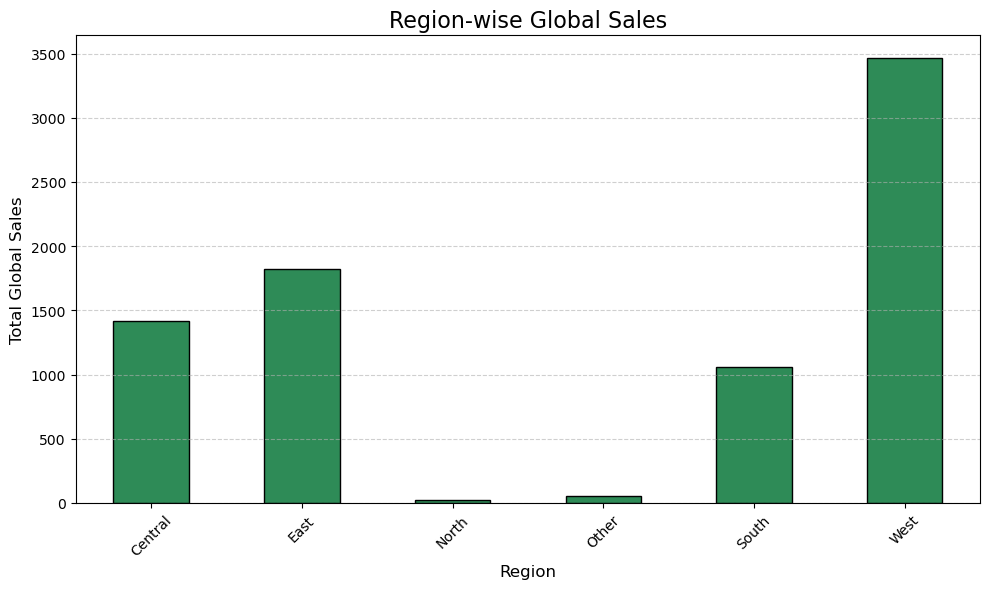

In [35]:

region_sales = df.groupby("Region")["Global_Sales"].sum()

plt.figure(figsize=(10,6))

region_sales.plot(
    kind="bar",
    color="#2E8B57",
    edgecolor="black"
)

plt.title("Region-wise Global Sales", fontsize=16)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Global Sales", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


# Growth %

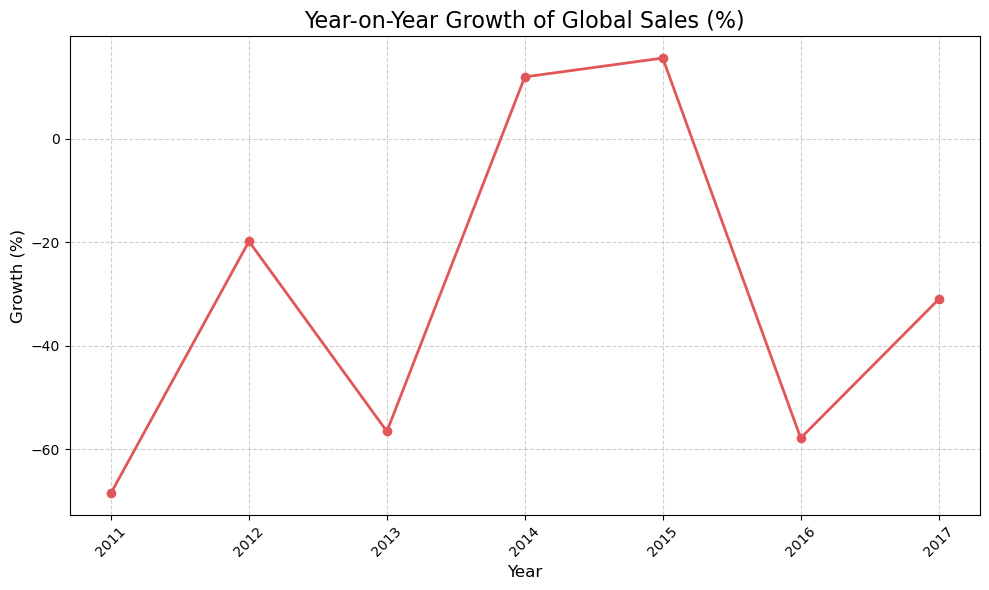

In [37]:

year_sales = df.groupby("Year")["Global_Sales"].sum()

growth_sales = year_sales.pct_change() * 100

plt.figure(figsize=(10,6))

growth_sales.plot(
    kind="line",
    marker="o",
    color="#E15759",
    linewidth=2
)

plt.title("Year-on-Year Growth of Global Sales (%)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Growth (%)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Publisher Market Share

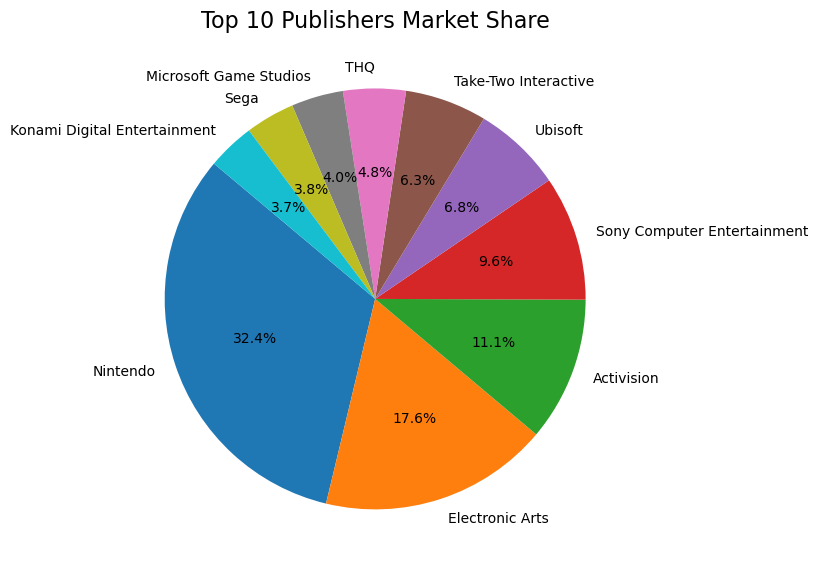

In [39]:

publisher_sales = df.groupby("Publisher")["Global_Sales"].sum()

market_share = (publisher_sales / publisher_sales.sum()) * 100

top_publishers = market_share.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,8))

top_publishers.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=140,
    colormap="tab10"
)

plt.title("Top 10 Publishers Market Share", fontsize=16)

plt.ylabel("")

plt.tight_layout()
plt.show()


# High Perfromance Segmantation

In [41]:

median_sales = df["Global_Sales"].median()

df["Performance"] = df["Global_Sales"].apply(
    lambda x: "High" if x > median_sales else "Low"
)

high_count = df[df["Performance"] == "High"].shape[0]

print("High Performers:", high_count)

High Performers: 2953
